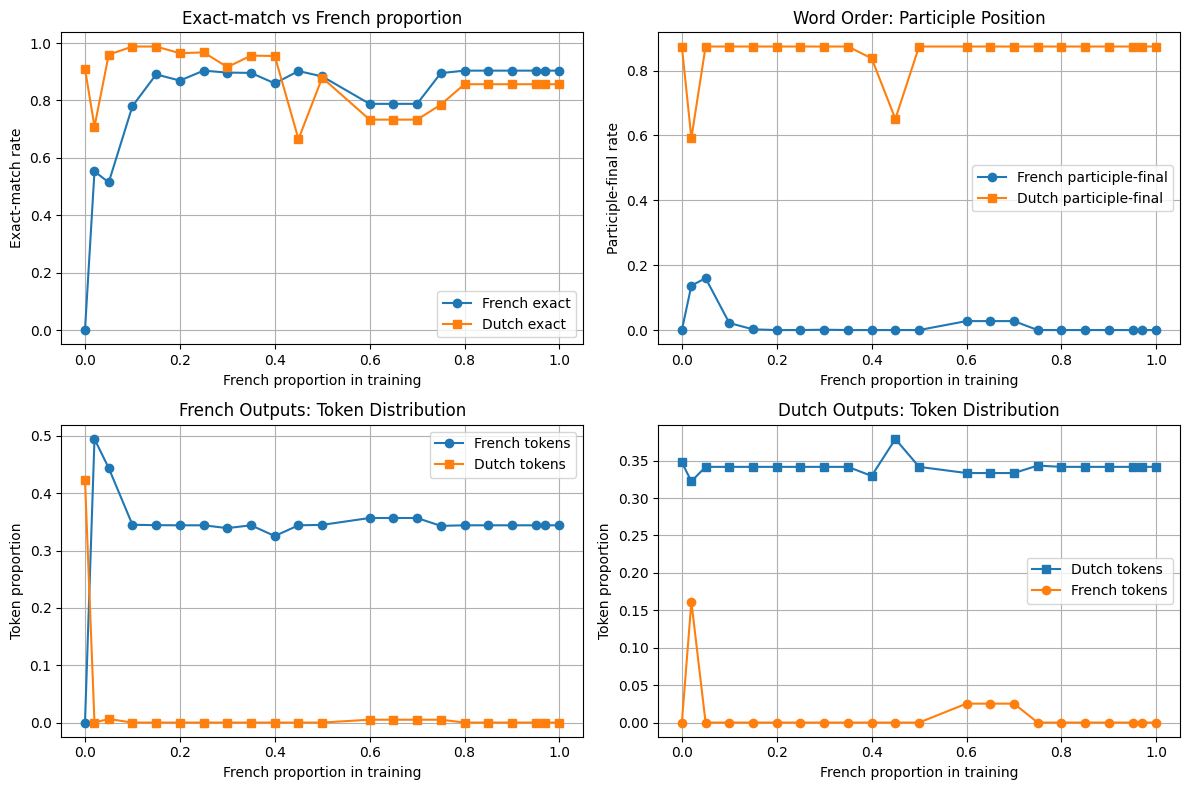

In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1) Collect all metrics.json under interactive_results_v2/*
records = []
for d in Path("interactive_results_v2").glob("small_p*_run*"):
    # folder name looks like "small_p05_run0", "small_p10_run1", etc.
    _, prop_str, _ = d.name.split("_")
    prop = int(prop_str[1:]) / 100.0

    metrics_path = d / "metrics.json"
    if not metrics_path.exists():
        continue

    with open(metrics_path, encoding="utf-8") as f:
        m = json.load(f)

    records.append({
        "prop":           prop,
        "fr_exact":       m.get("fr_exact"),
        "nl_exact":       m.get("nl_exact"),
        "fr_part_final":  m.get("fr_part_final"),
        "nl_part_final":  m.get("nl_part_final"),
        "fr_avg_fr":      m.get("fr_avg_fr"),
        "fr_avg_nl":      m.get("fr_avg_nl"),
        "nl_avg_fr":      m.get("nl_avg_fr"),
        "nl_avg_nl":      m.get("nl_avg_nl"),
    })

# 2) Build DataFrame, calculate means per proportion
df = pd.DataFrame(records)
df_mean = df.groupby("prop").mean().reset_index()
df_mean = df_mean.sort_values("prop")

# 1) Plot exact‐match curves
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.plot(df_mean["prop"], df_mean["fr_exact"], marker="o", label="French exact")
plt.plot(df_mean["prop"], df_mean["nl_exact"], marker="s", label="Dutch exact")
plt.xlabel("French proportion in training")
plt.ylabel("Exact‐match rate")
plt.title("Exact‐match vs French proportion")
plt.legend()
plt.grid(True)

# 2) Plot participle‐final rates (word order)
plt.subplot(2,2,2)
plt.plot(df_mean["prop"], df_mean["fr_part_final"], marker="o", label="French participle‐final")
plt.plot(df_mean["prop"], df_mean["nl_part_final"], marker="s", label="Dutch participle‐final")
plt.xlabel("French proportion in training")
plt.ylabel("Participle‐final rate")
plt.title("Word Order: Participle Position")
plt.legend()
plt.grid(True)

# 3) Plot French outputs language style
plt.subplot(2,2,3)
plt.plot(df_mean["prop"], df_mean["fr_avg_fr"], marker="o", label="French tokens")
plt.plot(df_mean["prop"], df_mean["fr_avg_nl"], marker="s", label="Dutch tokens")
plt.xlabel("French proportion in training")
plt.ylabel("Token proportion")
plt.title("French Outputs: Token Distribution")
plt.legend()
plt.grid(True)

# 4) Plot Dutch outputs language style
plt.subplot(2,2,4)
plt.plot(df_mean["prop"], df_mean["nl_avg_nl"], marker="s", label="Dutch tokens")
plt.plot(df_mean["prop"], df_mean["nl_avg_fr"], marker="o", label="French tokens")
plt.xlabel("French proportion in training")
plt.ylabel("Token proportion")
plt.title("Dutch Outputs: Token Distribution")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
